In [5]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

#-------------------------------
# DUSTY FSPS SPECTRUM
#-------------------------------
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)

In [6]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

In [3]:
sp.params['dust2']  

0.0

In [4]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 0
young_dust_index = -1

sp.params['dust2'] = 0
sp.params['dust1'] = 0
sp.params['dust_index'] = 1
sp.params['dust1_index'] = 1

wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 
print(sp.dust_mass)

0.0


In [44]:
sp.params['dust2'] = 0
sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4
sp.params['dust1_index'] = young_dust_index
sp.params['dust1'] = young_dust

wave, spec_fsps_dust_no_diffuse = sp.get_spectrum(tage=13.8) 
print(sp.dust_mass)

sp.params['dust2'] = diffdust
sp.params['dust_index'] = diffdust_index
sp.params['nebemlineinspec'] = False
wave, spec_fsps_only_att = sp.get_spectrum(tage=13.8) 
print(sp.dust_mass)


dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

0.0
0.0


(1e+52, 1e+64)

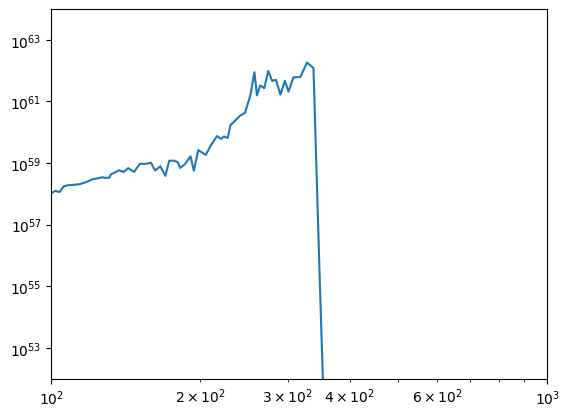

In [49]:
plt.loglog(wave, spec_fsps_dustfree/spec_fsps_only_att, label='no diffuse')
plt.xlim(1e2, 1e3)
plt.ylim(1e52, 1e64)

(1e-15, 0.01)

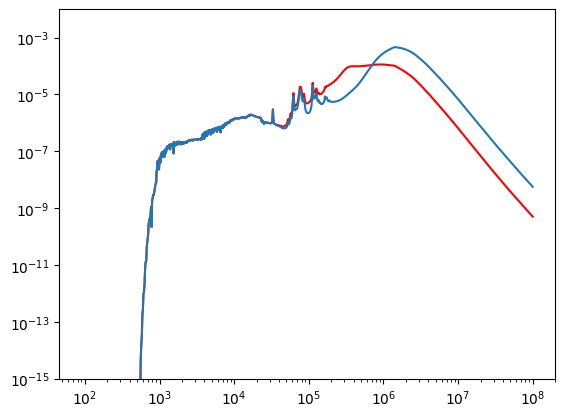

In [128]:
sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 1
wave, spec_fsps_hot = sp.get_spectrum(tage=13.8) 

sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 0
wave, spec_fsps_cold = sp.get_spectrum(tage=13.8) 



plt.loglog(wave, spec_fsps_hot, c = 'r', label='FSPS Dust Emission Hot')
plt.loglog(wave, spec_fsps_cold, label='FSPS Dust Emission Cold')

plt.ylim(1e-15, 1e-2)

In [102]:
dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}
emi_params = {'duste_qpah': 0.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
csp = CSPBasis(ssp_data, dusty=True, dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']})
print(csp.dust.get_default_fit_params())
csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum(dust_params=dust_params, emi_params=emi_params)
spec_dustfree = csp.get_spectrum_dustfree()

{'tau_pow': 1.0, 'alpha': 1.0, 'tau_kc': 1.0, 'dust_index': 0.0, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}
lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


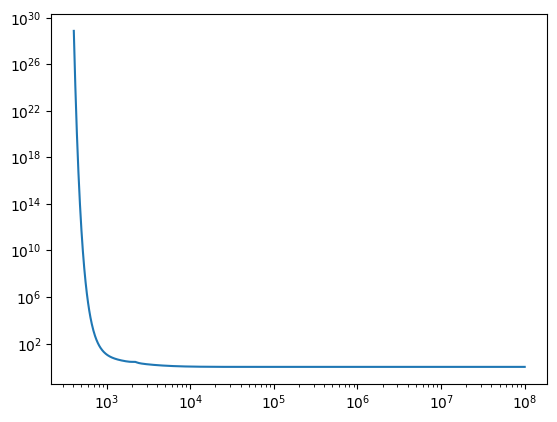

In [103]:
plt.loglog(csp.wave, spec_dustfree/spec, label='no diffuse (CSP)')

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


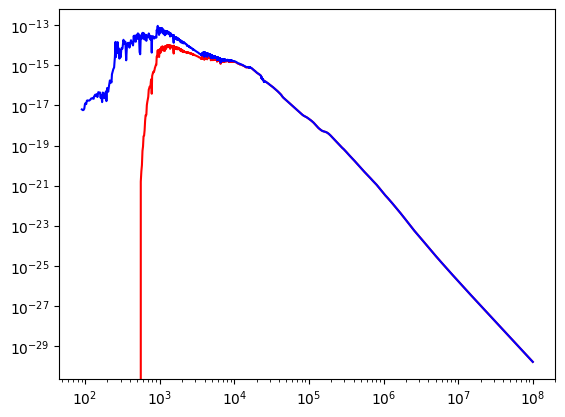

In [104]:
csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
emi_params = {'duste_qpah': 3.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
spec = csp.get_spectrum(dust_params=dust_params, emi_params=emi_params)
spec_dustfree = csp.get_spectrum_dustfree()

plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), label='CSP Dusty', color='red')
plt.plot(csp.wave, fnu2flam(csp.wave, spec_dustfree*1e-23*3631), label='CSP Dust-free', color='blue')
plt.yscale('log')
plt.xscale('log')



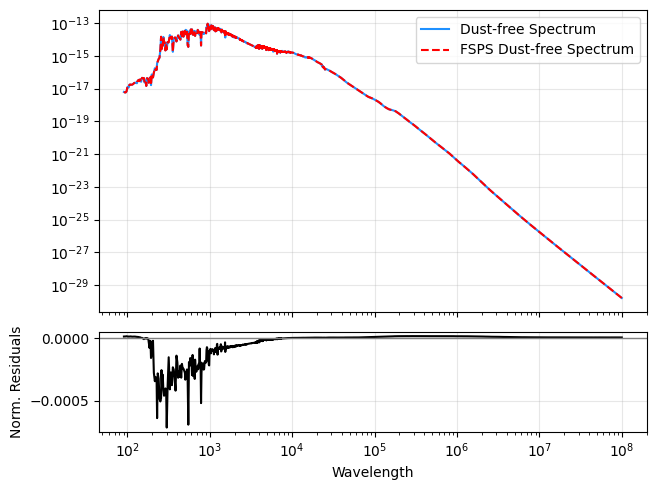

In [105]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,5), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax1.plot(csp.wave, fnu2flam(csp.wave, spec_dustfree*1e-23*3631), color = 'dodgerblue', label='Dust-free Spectrum')
ax1.plot(csp.wave, fnu2flam(csp.wave, spec_fsps_dustfree*1e-23*3631), '--', color = 'red', label='FSPS Dust-free Spectrum')
ax1.set_yscale('log'); ax1.set_xscale('log'); ax1.legend(); ax1.grid(True, alpha=0.3)

resid = (fnu2flam(csp.wave, spec_dustfree*1e-23*3631) - fnu2flam(csp.wave, spec_fsps_dustfree*1e-23*3631))
resid /= fnu2flam(csp.wave, spec_fsps_dustfree*1e-23*3631)
ax2.plot(csp.wave, resid, 'k'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [106]:
csp.diffuse

Array([2.8684656e+04, 2.5301373e+04, 2.3319684e+04, ..., 1.4457019e-15,
       1.4101305e-15, 1.3753762e-15], dtype=float32)

# Dust Attenuated Spectra

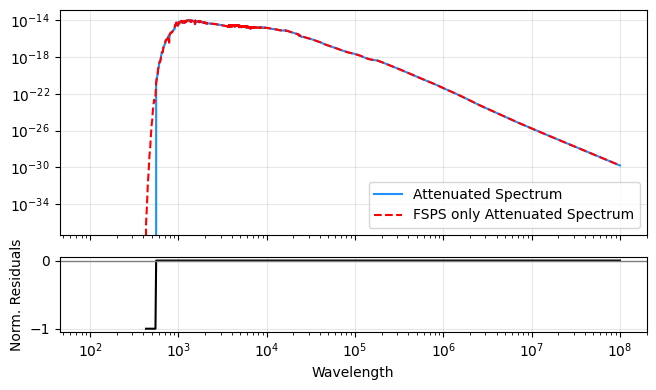

In [107]:
csp_attenuated = fnu2flam(csp.wave, spec*1e-23*3631)
fsps_attenuated = fnu2flam(csp.wave, spec_fsps_only_att*1e-23*3631) #fnu2flam(wave, spec_fsps_dustfree*jnp.exp(-csp.diffuse)*1e-23*3631)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,4), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax1.plot(csp.wave, csp_attenuated, color ='dodgerblue', label='Attenuated Spectrum')
#ax1.plot(csp.wave, fnu2flam(csp.wave, csp.spectrum_dust_no_diffuse *1e-23 * 3631), color ='green', label='CSP Spectrum No Diffuse')
ax1.plot(csp.wave, fsps_attenuated, '--', color = 'red', label='FSPS only Attenuated Spectrum')
#ax1.plot(csp.wave, fnu2flam(csp.wave, spec_fsps_dust_no_diffuse *1e-23 * 3631), '--', color = 'orange', label='FSPS only Attenuated Spectrum')

ax1.set_yscale('log'); ax1.set_xscale('log'); ax1.legend(); ax1.grid(True, alpha=0.3)

resid = (csp_attenuated - fsps_attenuated)
resid /= fsps_attenuated
ax2.plot(csp.wave, resid, color='k'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)
#ax1.set_ylim(10**-14.6, 10**-14.3)
#ax1.set_ylim(10**-17, 10**-13)

plt.tight_layout()

In [108]:
sp.params['nebemlineinspec']

False

In [109]:
fsps

<module 'fsps' from '/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/fsps/__init__.py'>

In [110]:
print('duste qpah:', sp.params['duste_qpah'])
print('duste umin:', sp.params['duste_umin'])
print('duste gamma:', sp.params['duste_gamma'])
print('add_agb_dust_model:', sp.params['agb_dust'])

duste qpah: 3.5
duste umin: 1.0
duste gamma: 1
add_agb_dust_model: 1.0


In [111]:
tiny_number = 1e-70

In [2]:
import jax.numpy as jnp
import jax

import numpy as np
from pathlib import Path

class DustEmission:

    def __init__(self, duste_model="DL07",
                 dust_file=None, spec_lambda=None, **kwargs):
        """
        Initialize the DustEmission object with parameters for dust emission modeling.

        Parameters
        ----------
        duste_model : str
            Dust emission model to use: 'DL07' or 'THEMIS'.
        dust_file : str
            Path to the dust emission file (required).
        spec_lambda : ndarray
            Wavelength grid over which dust emission will be evaluated (required).
        kwargs : dict
            Optional keyword arguments to override default dust parameters.
            Supported: duste_qpah, duste_umin, duste_gamma
        """

        # Store model choice (e.g., 'DL07' or 'THEMIS')
        self.duste_model = duste_model

        # Dust parameter values
        self.duste_qpah = None
        self.duste_umin = None
        self.duste_gamma = None

        # Model grid arrays for allowed values of qPAH and Umin
        self.qpaharr = None
        self.uminarr = None

        # Placeholder for loaded dust emission spectra
        self.dustem2_dustem = None

        # File path and wavelength grid
        self.dust_file = None
        self.spec_lambda = None

        # Store any additional keyword arguments for later use
        self.dwargs = kwargs

        # Read in key dust parameters, allowing overrides via kwargs
        self.duste_qpah = kwargs.pop("duste_qpah", 3.5)
        self.duste_umin = kwargs.pop("duste_umin", 1.0)
        self.duste_gamma = kwargs.pop("duste_gamma", 0.01)

        # Set parameter grids based on selected dust model
        if self.duste_model == "DL07":
            self.qpaharr = jnp.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
            self.uminarr = jnp.array([
                0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,2.0,
                2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0
            ])
        elif self.duste_model == "THEMIS":
            # THEMIS model uses smaller qPAH values rescaled to percent
            self.qpaharr = jnp.array([0.02, 0.06, 0.10, 0.14, 0.17, 0.20, 0.24,
                                      0.28, 0.32, 0.36, 0.40]) / 2.2 * 100
            self.uminarr = jnp.array([
                0.1, 0.12, 0.15, 0.17, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6,
                0.7, 0.8, 1.0, 1.2, 1.5, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0,
                6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 17.0, 20.0, 25.0, 30.0,
                35.0, 40.0, 50.0, 80.0
            ])
        else:
            raise ValueError("Invalid duste_model. Choose 'DL07' or 'THEMIS'.")

        # Ensure that necessary data is provided
        if dust_file is None or spec_lambda is None:
            raise ValueError("If `duste=True`, both `dust_file` and `spec_lambda` must be provided.")

        self.dust_file = dust_file
        self.spec_lambda = spec_lambda

        # Load emission templates or model data from file
        self.load_dust_emission(dust_file, spec_lambda)

    def __repr__(self):
        """
        Custom string representation of the DustEmission object.
        Provides a readable summary of model settings and parameters.
        """

        def format_array(arr):
            """Helper to format short arrays inline; longer arrays multiline."""
            if arr is None:
                return "None"
            if arr.ndim == 1 and len(arr) <= 5:
                return f"[{', '.join(map(str, arr))}]"
            return f"\n    " + "\n    ".join(map(str, arr))

        attributes = {
            "Duste model": self.duste_model,
            "DUST qPAH": self.duste_qpah,
            "DUST Umin": self.duste_umin,
            "DUST Gamma": self.duste_gamma,
            f"qpaharr ({self.duste_model})": format_array(self.qpaharr),
            f"uminarr ({self.duste_model})": format_array(self.uminarr),
            "dust_file": self.dust_file,
            "spec_lambda": self.spec_lambda.shape if self.spec_lambda is not None else None,
        }

        if self.dwargs:
            attributes["Extra parameters (dwargs)"] = self.dwargs

        attr_str = "\n".join(f"  {k:<30}: {v}" for k, v in attributes.items() if v is not None)
        return f"\nDustEmission Model:\n{'='*50}\n{attr_str}\n{'='*50}"


    def load_dust_emission(self, dust_file=None, spec_lambda=None):
        
        # Use default paths if not provided
        if dust_file is None:
            dust_file = self.dust_file
        if spec_lambda is None:
            spec_lambda = self.spec_lambda

        # Select dust model parameters
        dust_model_params = {
            "DL07": (7, 1001, 22),
            "THEMIS": (11, 576, 37),
        }
        
        nqpah_dustem, ndim_dustem, numin_dustem = dust_model_params[self.duste_model]

        # Initialize storage for interpolated spectra (JAX-compatible)
        dustem2_dustem = np.zeros((len(spec_lambda), nqpah_dustem, numin_dustem * 2))

        # Read and interpolate dust emission spectra
        for k in range(nqpah_dustem):
            filename = Path(dust_file) / "dust" / "dustem" / f"{self.duste_model}_MW3.1_{'100' if k == 10 else f'{k}0'}.dat"

            if not filename.exists():
                raise FileNotFoundError(f"Error opening dust emission file: {filename}. File does not exist.")

            with filename.open('r') as f:
                next(f)  # Skip first header line
                next(f)  # Skip second header line

                lambda_dustem = np.zeros(ndim_dustem)
                dustem_dustem = np.zeros((ndim_dustem, numin_dustem * 2))

                for i in range(ndim_dustem):
                    try:
                        values = list(map(float, f.readline().strip().split()))
                        lambda_dustem[i], dustem_dustem[i, :] = values[0], values[1:]
                    except Exception:
                        raise RuntimeError(f"Error reading dust emission file: {filename}")

            # Convert wavelength from microns to Angstroms
            lambda_dustem *= 1E4

            # Interpolate dust spectra onto the master wavelength array
            jj = jnp.searchsorted(spec_lambda / 1E4, 1, side='left')
            for j in range(numin_dustem * 2):
                dustem2_dustem[jj:, k, j] = jnp.interp(spec_lambda[jj:], lambda_dustem, dustem_dustem[:, j])

        self.dustem2_dustem = jnp.array(dustem2_dustem)

    def update_dust_params(self, duste_qpah = 3.5, duste_umin = 1.0, duste_gamma = 0.01):
        """
        Update dust parameters for emission calculations.

        Parameters:
            duste_qpah (float, optional): New PAH fraction.
            duste_umin (float, optional): New minimum U radiation field.
            duste_gamma (float, optional): New fraction of high U component.
        """
        self.duste_qpah = duste_qpah
        self.duste_umin = duste_umin
        self.duste_gamma = duste_gamma

    def compute_dust_emission(self, spec_attn, spec_dustfree, spec_lambda, diffuse_curve,
                                        duste_qpah=None, duste_umin=None, duste_gamma=None):
        """
        Compute dust emission using JAX-optimized vectorization for GPU acceleration.

        Parameters:
            spec_attn (jnp.ndarray): Attenuated spectrum after dust absorption.
            spec_dustfree (jnp.ndarray): Stellar spectrum before attenuation.
            spec_lambda (jnp.ndarray): Wavelength array in Angstroms.
            duste_qpah (float, optional): PAH fraction. Defaults to self.duste_qpah if None.
            duste_umin (float, optional): Minimum U radiation field. Defaults to self.duste_umin if None.
            duste_gamma (float, optional): Fraction of high U component. Defaults to self.duste_gamma if None.

        Returns:
            tuple: (Updated spectrum with dust emission added, Estimated dust mass)
        """

        # Use provided parameters if given, otherwise fallback to self attributes
        duste_qpah = self.duste_qpah
        duste_umin = self.duste_umin
        duste_gamma = self.duste_gamma


        print(f"Using dust parameters: qPAH={duste_qpah}, Umin={duste_umin}, gamma={duste_gamma}")

        def tsum(x, y):
            nn = len(x)
            tsum = jnp.sum(jnp.abs((x[1:nn] - x[0:nn-1])) * (y[1:nn] + y[0:nn-1]) / 2.0)
            return tsum
        C_ANG_PER_S = 2.99792458e18  # speed of light in Angstrom/s
        # Compute total luminosity before and after attenuation
        nu = const.c * 10**10 / (spec_lambda)  # Frequency in Hz (c / λ)
        lbold = tsum(csp.wave, spec_attn * C_ANG_PER_S / csp.wave**2)#jnp.trapezoid(spec_attn, x=nu)
        lboln = tsum(csp.wave, spec_dustfree* C_ANG_PER_S / csp.wave**2)#jnp.trapezoid(spec_dustfree, x=nu)  # L_bol before attenuation
        # Interpolation indices for PAH fraction and Umin
        qlo = jnp.clip(jnp.searchsorted(self.qpaharr, duste_qpah) - 1, 0, len(self.qpaharr) - 2)
        dq = jnp.clip((duste_qpah - self.qpaharr[qlo]) / (self.qpaharr[qlo + 1] - self.qpaharr[qlo]), 0.0, 1.0)
        ulo = jnp.clip(jnp.searchsorted(self.uminarr, duste_umin) - 1, 0, len(self.uminarr) - 2)
        du = jnp.clip((duste_umin - self.uminarr[ulo]) / (self.uminarr[ulo + 1] - self.uminarr[ulo]), 0.0, 1.0)
    

        # Ensure gamma fraction is within [0,1]
        gamma = jnp.clip(duste_gamma, 0.0, 1.0)

        # Perform bilinear interpolation over qpah and Umin using `vmap`
        def interpolate_dustem(i):
            return (
                (1 - dq) * (1 - du) * self.dustem2_dustem[i, qlo, 2 * ulo - 1] +
                dq * (1 - du) * self.dustem2_dustem[i, qlo + 1, 2 * ulo - 1] +
                dq * du * self.dustem2_dustem[i, qlo + 1, 2 * (ulo + 1) - 1] +
                (1 - dq) * du * self.dustem2_dustem[i, qlo, 2 * (ulo + 1) - 1]
            ), (
                (1 - dq) * (1 - du) * self.dustem2_dustem[i, qlo, 2 * ulo] +
                dq * (1 - du) * self.dustem2_dustem[i, qlo + 1, 2 * ulo] +
                dq * du * self.dustem2_dustem[i, qlo + 1, 2 * (ulo + 1)] +
                (1 - dq) * du * self.dustem2_dustem[i, qlo, 2 * (ulo + 1)]
            )

        dumin, dumax = jax.vmap(interpolate_dustem)(jnp.arange(len(spec_lambda)))
        self.dumin = dumin
        self.dumax = dumax

        # Compute dust emission spectrum
        mduste = (1 - gamma) * dumax + gamma * dumin
        mduste = jnp.maximum(mduste, tiny_number)
        print(mduste)
        self.mduste = mduste
        # Normalize to absorbed luminosity
        labs =  lboln - lbold  # Energy absorbed by dust
        self.labs = labs
        norm = tsum(csp.wave, mduste* C_ANG_PER_S / csp.wave**2)  # Normalization factor
        self.norm = norm
        duste = jnp.maximum(mduste / norm * labs, tiny_number)  # Normalize dust emission

        #duste = jnp.maximum(duste, tiny_number)
        self.duste = duste
        tduste = jnp.zeros_like(duste)

        diff_dust = jnp.exp(-diffuse_curve)  # Apply diffuse dust attenuation

    
       
       # --- JAX while_loop implementation ---
        def body_fn(state):
            """
            The main loop body, which performs one iteration of dust self-absorption.
            All variables that change must be part of the state tuple.
            """
            duste, lboln_in, lbold_in, tduste_in, iself = state

            oduste = duste # old dust distribution (before absorption)
            duste_out = duste * diff_dust # Apply self-absorption attenuation
            tduste_out = tduste_in + duste_out

            # TSUM is an integration
            lbold_out = tsum(csp.wave, duste_out* C_ANG_PER_S / csp.wave**2)  # L_bol after self-absorption
            lboln_out = tsum(csp.wave, oduste* C_ANG_PER_S / csp.wave**2)  # L_bol before self-absorption

            # Recalculate duste for the next iteration
            duste_next = jnp.maximum(mduste / norm * (lboln_out - lbold_out), tiny_number)

            return (duste_next, lboln_out, lbold_out, tduste_out, 1)

        def cond_fn(state):
            """
            The loop condition function.
            FSPS: DO WHILE (((lboln-lbold).GT.1E-2).OR.iself.EQ.0)
            Means: run while difference > 1e-2 OR at least once
            """
            duste, lboln, lbold, tduste, iself = state
            return jnp.logical_or((lboln - lbold) > 1e-2, iself == 0)

        # Initial state for the loop (iself=0 to ensure at least one iteration)
        initial_state = (duste, lboln, lbold, tduste, 0)


        # Execute the while loop
        duste_next, _, _, tduste_out, _ = jax.lax.while_loop(cond_fn, body_fn, initial_state)



        # --- Final calculations after the loop ---
        # Compute estimated dust mass
        mdust = 3.21E-3 / (4 * jnp.pi) * labs / norm
    
        
        return duste_next, tduste_out, mdust
    
def tsum(x, y):
    nn = len(x)
    tsum = jnp.sum(jnp.abs((x[1:nn] - x[0:nn-1])) * (y[1:nn] + y[0:nn-1]) / 2.0)
    return tsum

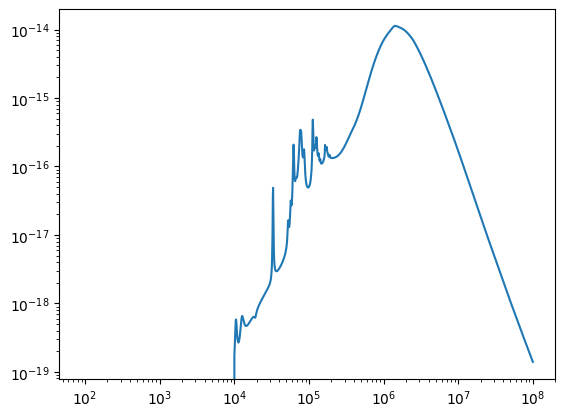

In [148]:
plt.loglog(csp.wave,emi.mduste)

In [149]:
from pathlib import Path

file_path = Path("/Users/amanda/Prospector/fsps/dust/dustem/DL07_MW3.1_20.dat")

with open(file_path, "r") as f:
    header_lines = [next(f).rstrip("\n") for _ in range(2)]

print("Header lines:")
for line in header_lines:
    print(line)

Header lines:
# lambda (um), Umin,min, Umin,max for Umin=0.10, 0.15,...25.0
# dust emission spectra are in units of Lnu (specifically, Jy cm2 sr-1 H-1); 3.3um PAH reduced by 50%


In [4]:
emi = DustEmission(spec_lambda=csp.wave, dust_file='/Users/amanda/Prospector/fsps')

emi.update_dust_params(duste_qpah=sp.params['duste_qpah'], duste_umin=sp.params['duste_umin'], duste_gamma=sp.params['duste_gamma'])
duste_next, tduste_out1, mdust1 = emi.compute_dust_emission(spec_attn = spec, spec_dustfree=csp.spectrum_dust_no_diffuse, spec_lambda=wave, diffuse_curve=csp.diffuse)

emi.update_dust_params(duste_qpah=sp.params['duste_qpah'], duste_umin=sp.params['duste_umin'], duste_gamma=0)
duste_next, tduste_out2, mdust2 = emi.compute_dust_emission(spec_attn = fsps_attenuated, spec_dustfree=spec_fsps_dustfree, spec_lambda=wave, diffuse_curve=csp.diffuse)

NameError: name 'csp' is not defined

In [3]:
iself = 0

dustem2_dustem = emi.dustem2_dustem

duste_qpah = sp.params['duste_qpah']
duste_umin = sp.params['duste_umin']
duste_gamma = sp.params['duste_gamma']

diff_dust = spec_diffuse / spec_dustfree

# Constants
clight = const.c.value # speed of light in m/s
tiny_number = 1e-70     # small floor value to avoid division by zero
mypi = np.pi
spec_lambda = csp.wave  # assuming csp.wave is in Angstroms
specdust = spec_diffuse.copy()
specdustfree = spec_dustfree.copy()

qpaharr = np.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
nqpah_dustem = len(qpaharr)
uminarr = np.array([0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,2.0,2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0])
numin_dustem = len(uminarr)
# Compute nu = c / lambda, where lambda is in Angstroms
nu = clight * 1e10 / spec_lambda  # assuming spec_lambda is in Angstroms

# Compute total bolometric luminosity before and after attenuation
lbold = np.trapezoid(specdust, nu)  # TSUM is assumed to be a trapezoidal integral
lboln = np.trapezoid((specdustfree), nu)


# --- QPAH interpolation ---
qlo = max(min(np.searchsorted(qpaharr, duste_qpah) - 1, nqpah_dustem - 2), 0)
dq = (duste_qpah - qpaharr[qlo]) / (qpaharr[qlo + 1] - qpaharr[qlo])
dq = min(max(dq, 0.0), 1.0)

# --- Umin interpolation ---
ulo = max(min(np.searchsorted(uminarr, duste_umin) - 1, numin_dustem - 1), 0)
du = (duste_umin - uminarr[ulo]) / (uminarr[ulo + 1] - uminarr[ulo])
du = min(max(du, 0.0), 1.0)

# --- gamma limiting ---
gamma = max(min(duste_gamma, 1.0), 0.0)

# --- bilinear interpolation ---
# Remember: Python uses 0-based indexing
dumin = (
    (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo] +
    dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo] +
    dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
    (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1)]
)

dumax = (
    (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo + 1] +
    dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
    dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
    (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
)

# Combine both parts of P(U) dU
mduste = (1 - gamma) * dumin + gamma * dumax
mduste = np.maximum(mduste, tiny_number)

# Normalize the dust emission to match the absorbed luminosity
labs = lboln - lbold
norm = np.trapezoid(mduste, nu)
duste = mduste / norm * labs
duste = np.maximum(duste, tiny_number)

# --- Include dust self-absorption iteratively ---
tduste = np.zeros_like(duste)
counter = 0

dustearr = []
while (abs(lboln - lbold) > 1e-2) and  (counter < 3):
    oduste = duste.copy()
    duste = duste * diff_dust  # apply dust self-absorption curve
    tduste += duste

    lbold = np.trapezoid(duste, nu)     # after absorption
    lboln = np.trapezoid(oduste, nu)    # before absorption

    duste = np.maximum(mduste / norm * (lboln - lbold), tiny_number)
    dustearr.append(tduste)
    counter += 1
    print('lbold:', lbold)
    print('lboln:', lboln)
    print(tduste)

print('Dust self-absorption iteration:', counter)

# Compute final dust mass
mdust = 3.21e-3 / (4 * mypi) * labs / norm

# Add dust emission to original dust spectrum
specdust += tduste

# Debug call (replace with real function if needed)
# dust_debug_set(nspec, mduste, tduste, duste, specdust, labs, norm, mdust)

# If nebemlineinspec ≠ 0
# (in Fortran this was inside the ELSE branch)


NameError: name 'emi' is not defined

# Add Dust Emission

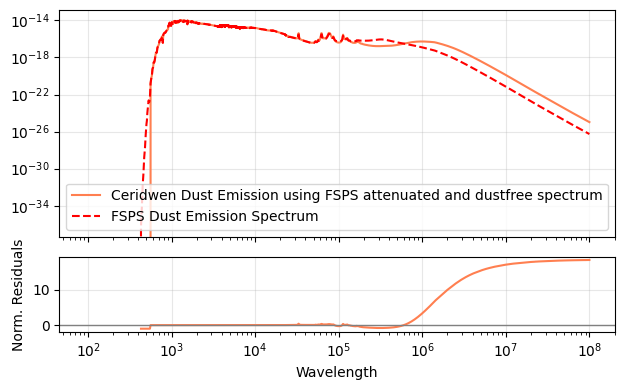

In [151]:
csp_emi = fnu2flam(csp.wave, (spec + tduste_out1)*1e-23*3631)
csp_emi2 = fnu2flam(csp.wave, (spec + tduste_out2)*1e-23*3631)

fsps_emi = fnu2flam(csp.wave, spec_fsps*1e-23*3631) #fnu2flam(wave, spec_fsps_dustfree*jnp.exp(-csp.diffuse)*1e-23*3631)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,4), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
#ax1.plot(csp.wave, csp_emi, color ='dodgerblue', label='Ceridwen Dust Emission Spectrum')
#ax1.plot(csp.wave, fnu2flam(csp.wave, csp.spectrum_dust_no_diffuse *1e-23 * 3631), color ='green', label='CSP Spectrum No Diffuse')
#ax1.plot(csp.wave, fnu2flam(csp.wave, spec_fsps_only_att *1e-23 * 3631), color ='purple', label='CSP Dust-free Spectrum')
ax1.plot(csp.wave, csp_emi2, color ='coral', label='Ceridwen Dust Emission using FSPS attenuated and dustfree spectrum')
ax1.plot(csp.wave, fsps_emi, '--', color = 'red', label='FSPS Dust Emission Spectrum')


ax1.set_yscale('log');ax1.set_xscale('log');  ax1.legend(); ax1.grid(True, alpha=0.3)
resid = (csp_emi - fsps_emi)
resid /= fsps_emi

resid2 = (csp_emi2 - fsps_emi)
resid2 /= fsps_emi
#ax2.plot(csp.wave, resid, color='dodgerblue'); ax2.axhline(0, color='gray', lw=1)
ax2.plot(csp.wave, resid2, color='coral'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)
#ax1.set_xlim(2*1e4, 1e8)

#ax1.set_ylim(10**-20, 10**-15)
plt.tight_layout()

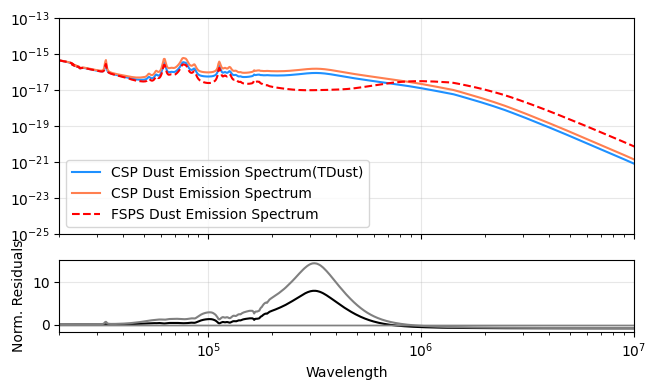

In [100]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,4), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax1.plot(csp.wave, csp_emi, color ='dodgerblue', label='CSP Dust Emission Spectrum(TDust)')
ax1.plot(csp.wave, csp_emi2, color ='coral', label='CSP Dust Emission Spectrum ')
ax1.plot(csp.wave, fsps_emi, '--', color = 'red', label='FSPS Dust Emission Spectrum')


ax1.set_yscale('log');ax1.set_xscale('log');  ax1.legend(); ax1.grid(True, alpha=0.3)
resid = (csp_emi - fsps_emi)
resid /= fsps_emi

resid2 = (csp_emi2 - fsps_emi)
resid2 /= fsps_emi
ax2.plot(csp.wave, resid, color='k'); ax2.axhline(0, color='gray', lw=1)
ax2.plot(csp.wave, resid2, color='gray'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)
ax1.set_xlim(2*1e4, 1e7)

ax1.set_ylim(10**-25, 10**-13)
plt.tight_layout()

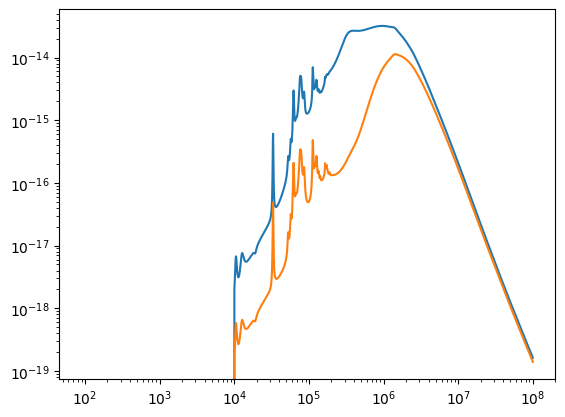

In [22]:
plt.loglog(csp.wave, emi.dumin, label='dumin')
plt.loglog(csp.wave, emi.dumax, label='dumax')

In [23]:
def fnu2flam(lam, fnu):
    """Convert f_nu [erg/s/cm^2/Hz] to f_lambda [erg/s/cm^2/Å]."""
    c = 2.998e18  # Å/s
    return c * fnu / (lam**2)


In [24]:
import pickle as pkl

fsps_path= Path('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/spec_lambda.pkl')
with fsps_path.open('wb') as f:
    pkl.dump(csp.wave, f)

In [25]:
sp.params['nebemlineinspec']

True

In [26]:
with open('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/fsps_emi.pkl', 'rb') as f:
    fsps_emi = pkl.load(f)


In [27]:
emi.dustem2_dustem.shape

(5994, 7, 44)

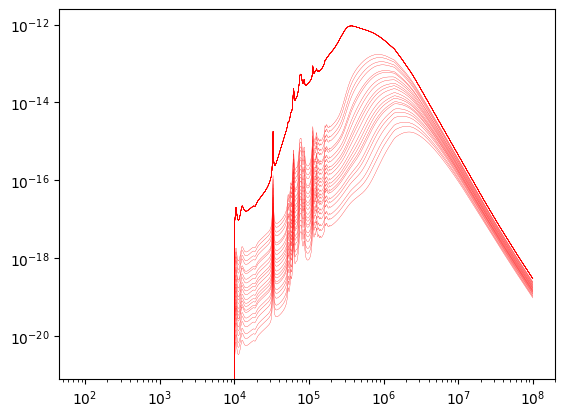

In [28]:
for i in range(1):
    for k in range(44):
        plt.loglog(csp.wave, emi.dustem2_dustem[:, i, 2*k], lw = 0.2, color = 'r', label=f'Umin={emi.uminarr[k]}, qPAH={emi.qpaharr[i]}')

In [29]:
spec_fsps_only_att

array([1.00000000e-70, 1.00000000e-70, 1.00000000e-70, ...,
       1.56621688e-13, 1.53748135e-13, 1.50918510e-13], shape=(5994,))

In [30]:
C_ANG_PER_S = 2.99792458e18  # speed of light in Å/s

def bolometric_from_Lnu(lam, Lnu):
    lam = np.asarray(lam)
    nu  = C_ANG_PER_S / lam
    return tsum(lam, Lnu * C_ANG_PER_S / lam**2)


def energy_budget(lam, Lint, Ltrans, Ldust):

    I = bolometric_from_Lnu(lam, Lint)
    T = bolometric_from_Lnu(lam, Ltrans)
    D = bolometric_from_Lnu(lam, Ldust)
    print(I, T, D)

    resid = I - (T + D)
    frac  = resid / I if I != 0 else np.nan
    return dict(Lint=I, Ltrans=T, Ldust=D, residual=resid, frac_err=frac)

In [31]:
res_csp = energy_budget(
    lam = csp.wave,  
    Lint   = csp.spectrum_dust_no_diffuse,  # intrinsic (no dust)
    Ltrans = spec,                           # after attenuation (no dust emission)
    Ldust  = tduste_out1,                    # dust emission
)
print("CSP Δ/Lint =", res_csp["frac_err"], res_csp['residual'])

2469381000.0 1035747100.0 1433634200.0
CSP Δ/Lint = 0.0 0.0


In [32]:
sp._all_ssp_spec.

SyntaxError: invalid syntax (1581164261.py, line 1)

In [33]:
dust_only_fsps = spec_fsps - spec_fsps_only_att
dust_only_fsps = np.maximum(dust_only_fsps, 0.0)

res_fsps = energy_budget(
    lam = csp.wave,                         # FSPS wavelength array [Å]
    Lint   = spec_fsps_dust_no_diffuse,     # pre-attenuation spectrum
    Ltrans = spec_fsps_only_att,               # after attenuation (no dust emission)
    Ldust  = dust_only_fsps,                # derived dust emission
)
print("FSPS Δ/Lint =", res_fsps["frac_err"], res_fsps['residual'])

2469584000.0 1035772600.0 1434001800.0
FSPS Δ/Lint = -7.712392e-05 -190464.0


CSP energy budget:
  L_int        = 2.469381e+09
  L_trans      = 1.035747e+09
  L_dust       = 1.433634e+09
  Residual     = 0.000000e+00
  Δ/L_int      = 0.000000e+00


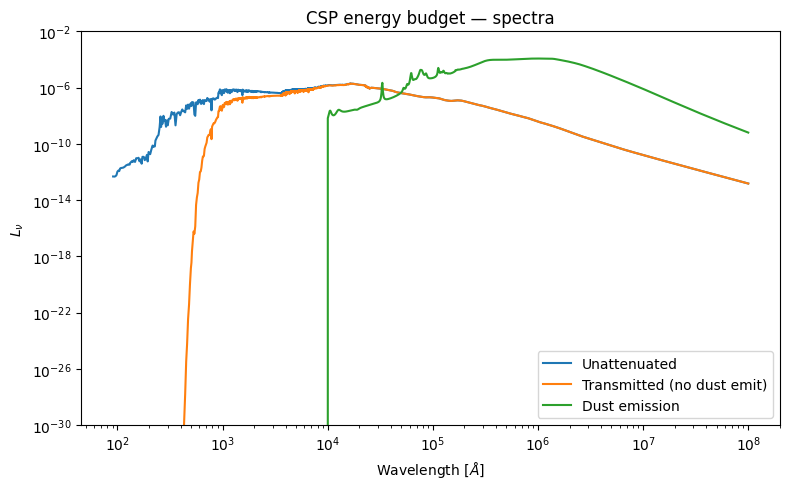

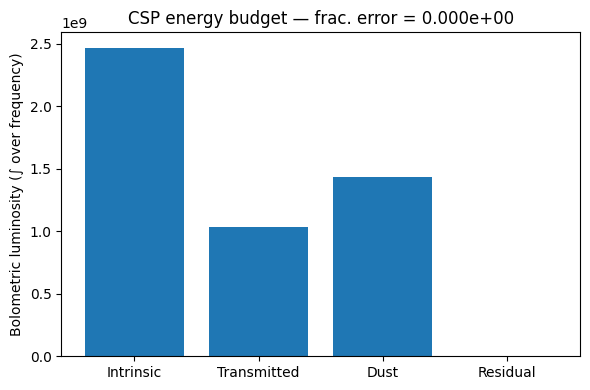

In [34]:


C_ANG_PER_S = 2.99792458e18  # c in Å/s



def visualize_energy_budget(lam, Lint, Ltrans, Ldust, per='nu', title='CSP energy budget'):
    lam = np.asarray(lam)
    assert np.all(np.diff(lam) > 0), "lam must be strictly increasing"

    if per == 'nu':
        I = bolometric_from_Lnu(lam, Lint)
        T = bolometric_from_Lnu(lam, Ltrans)
        D = bolometric_from_Lnu(lam, Ldust)
        ylab = r"$L_\nu$"
    elif per == 'lam':
        I = tsum(lam, Lint  * (C_ANG_PER_S/lam**2))
        T = tsum(lam, Ltrans* (C_ANG_PER_S/lam**2))
        D = tsum(lam, Ldust * (C_ANG_PER_S/lam**2))
        ylab = r"$L_\lambda$"
    else:
        raise ValueError("per must be 'nu' or 'lam'")

    resid   = I - (T + D)
    fracerr = resid / I if I != 0 else np.nan

    # --- 1) Spectra plot ---
    plt.figure(figsize=(8, 5))
    plt.loglog(lam, np.maximum(Lint, 1e-300), label="Unattenuated")
    plt.loglog(lam, np.maximum(Ltrans, 1e-300), label="Transmitted (no dust emit)")
    plt.loglog(lam, np.maximum(Ldust, 1e-300), label="Dust emission")
    plt.ylim(1e-30, 1e-2)
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(ylab)
    plt.title(title + " — spectra")
    plt.legend()
    plt.tight_layout()

    # --- 2) Integrated energy bars ---
    plt.figure(figsize=(6, 4))
    names = ["Intrinsic", "Transmitted", "Dust", "Residual"]
    vals  = [I, T, D, resid]
    xpos  = np.arange(len(names))
    plt.bar(xpos, vals)
    plt.xticks(xpos, names)
    plt.ylabel("Bolometric luminosity (∫ over frequency)")
    plt.title(title + f" — frac. error = {fracerr:.3e}")
    plt.tight_layout()

    # Print numbers for the record
    print(f"{title}:")
    print(f"  L_int        = {I:.6e}")
    print(f"  L_trans      = {T:.6e}")
    print(f"  L_dust       = {D:.6e}")
    print(f"  Residual     = {resid:.6e}")
    print(f"  Δ/L_int      = {fracerr:.6e}")

    return dict(Lint=I, Ltrans=T, Ldust=D, residual=resid, frac_err=fracerr)

# ---- Use it for your CSP data ----
res_csp_viz = visualize_energy_budget(
    lam=csp.wave,
    Lint=csp.spectrum_dust_no_diffuse,   # intrinsic (no diffuse dust)
    Ltrans=spec,                          # attenuated (no dust emission)
    Ldust=tduste_out1,                    # escaping dust emission
    per='nu'                              # change to 'lam' if these are per-λ spectra
)



In [35]:
sp.zlegend

array([4.49043431e-05, 1.42000001e-04, 2.52515678e-04, 4.49043431e-04,
       7.98524687e-04, 1.42000001e-03, 2.52515678e-03, 4.49043431e-03,
       7.98524687e-03, 1.42000001e-02, 2.52515678e-02, 4.49043431e-02])

FSPS energy budget:
  L_int        = 2.469584e+09
  L_trans      = 1.035773e+09
  L_dust       = 1.434002e+09
  Residual     = -1.904640e+05
  Δ/L_int      = -7.712392e-05


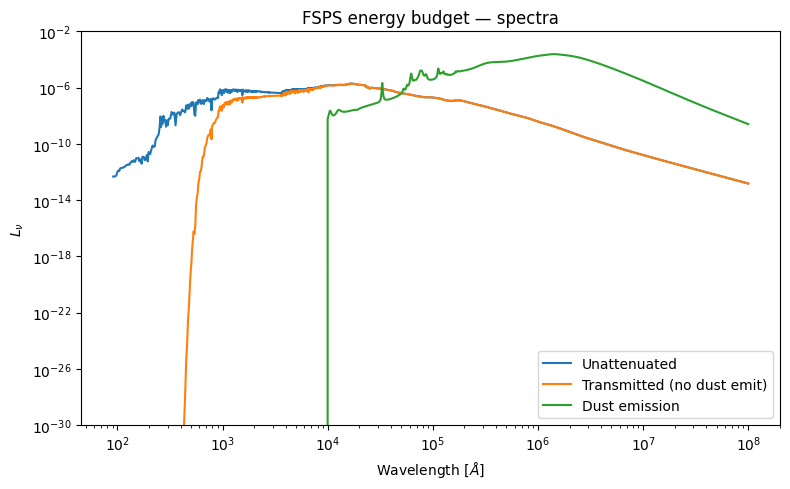

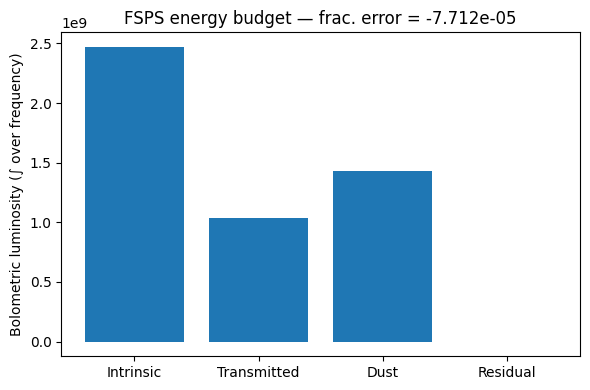

In [36]:
res_fsps_viz = visualize_energy_budget(
    lam=csp.wave,                         # FSPS wavelength array [Å]
    Lint=spec_fsps_dust_no_diffuse,     # pre-attenuation spectrum
    Ltrans=spec_fsps_only_att,               # after attenuation (no dust emission)
    Ldust=dust_only_fsps,                # derived dust emission
    per='nu',                              # change to 'lam' if these are per-λ spectra
    title='FSPS energy budget'
)